## Malware Detection ML

This project aims to reproduce and extend the Malware Detection benchmark from the pcapML/nPrint suite. The goal is to identify malicious (malware) and benign traffic flows within the dataset using packet-level and flow-level network data.

This is an important real-world problem because modern malware often hides its activity within encrypted or obfuscated traffic, making it necessary to detect attacks using metadata and flow features rather than inspecting payloads directly. Accurate malware detection from network data is critical for preventing data breaches and improving enterprise or ISP-level defenses.

This project aligns closely with the course theme by applying machine learning to network security, showing how models can learn from traffic patterns instead of raw content. Related work includes studies leveraging flow-based features such as Time-To-Live (TTL) and packet timing statistics for intrusion detection, though these often rely too heavily on limited attributes.

The main goal is to reproduce the published benchmark and extend it by introducing new feature metrics tailored for malware detection. Ultimately, the project aims to create a generalizable, open-source model that can be easily reused and deployed, hosted on GitHub with documentation for other researchers.



In [20]:
# imports 
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd
from scapy.all import *

### Data Exploration

Label of this data is encoded in the pcapng as a metadata

Feature engineering

In [ ]:
import zipfile
import os
import pandas as pd

zip_path = "traffic_flow_features_binary_custom.zip"

extract_dir = "traffic_data"

if not os.path.exists(extract_dir):
    print("Unzipping dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print("Dataset already unzipped.")

csv_path = os.path.join(extract_dir, "traffic_flow_features_binary_custom.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

(498446, 12)
   pkt_count  bytes_sum  pkt_size_mean  pkt_size_median  pkt_size_min  \
0        4.0      868.0          217.0            217.0         217.0   
1        4.0      864.0          216.0            216.0         216.0   
2        2.0      128.0           64.0             64.0          64.0   
3        4.0      868.0          217.0            217.0         217.0   
4        2.0      136.0           68.0             68.0          68.0   

   pkt_size_max  pkt_size_std  flow_duration      iat_mean       iat_std  \
0         217.0           0.0   1.288497e+10  4.294991e+09  23715.960744   
1         216.0           0.0   1.288490e+10  4.294968e+09   5589.445470   
2          64.0           0.0   4.095170e+05  4.095170e+05      0.000000   
3         217.0           0.0   1.288492e+10  4.294974e+09   8600.843021   
4          68.0           0.0   4.294376e+09  4.294376e+09      0.000000   

        iat_max  label  
0  4.295024e+09      1  
1  4.294974e+09      1  
2  4.095170e+05 

In [17]:
# class balance
df["label"].value_counts()

label
1    369325
0    129121
Name: count, dtype: int64

### Model training and evaluation

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

df = pd.read_csv(r"C:\Users\wpca4\Desktop\CMSC\traffic_flow_features_binary_custom.csv")

X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [24]:
# helper functions for evaluation

def print_metrics(y_true, y_pred, y_score, name="model"):
    acc  = accuracy_score(y_true, y_pred)
    bal  = balanced_accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_score)

    print(f"\n===== {name} =====")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Balanced Accuracy : {bal:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print(f"ROC AUC           : {auc:.4f}")


def plot_confusion(y_true, y_pred, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
    fig, ax = plt.subplots()
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc(y_true, y_score, title="ROC curve"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc  = roc_auc_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Unsupservised Leraning Methods

OCSVM

In [25]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report

X_train_benign = X_train[y_train == 0]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_benign)
X_test_sc  = scaler.transform(X_test)

ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.1,   
    gamma="scale",
)
ocsvm.fit(X_train_sc)

y_pred_oc = ocsvm.predict(X_test_sc) 
y_pred_label = (y_pred_oc == -1).astype(int)


cm = confusion_matrix(y_test, y_pred_label)
bal_acc = balanced_accuracy_score(y_test, y_pred_label)
print("Confusion matrix:\n", cm)
print("Balanced accuracy:", bal_acc)

print("\nClassification report:\n", classification_report(y_test, y_pred_label, digits=4))

Confusion matrix:
 [[34835  3901]
 [73453 37345]]
Balanced accuracy: 0.6181737340751889

Classification report:
               precision    recall  f1-score   support

           0     0.3217    0.8993    0.4739     38736
           1     0.9054    0.3371    0.4912    110798

    accuracy                         0.4827    149534
   macro avg     0.6136    0.6182    0.4826    149534
weighted avg     0.7542    0.4827    0.4867    149534



### Supervised Learning Methods

Logistic Regression Model


===== LogisticRegression =====
Accuracy          : 0.6145
Balanced Accuracy : 0.4667
F1-score          : 0.7483
ROC AUC           : 0.4435


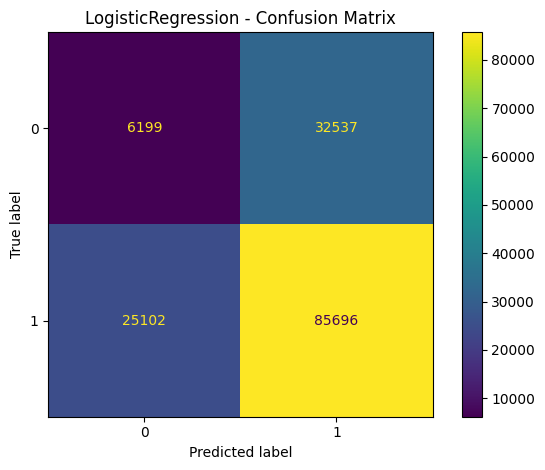

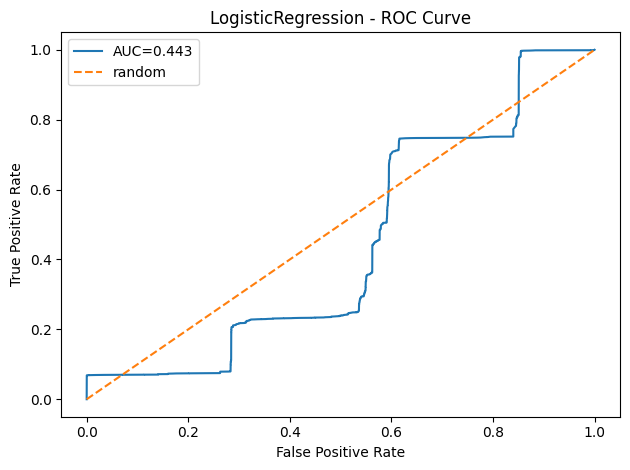

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    n_jobs=-1,
)

lr.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_test)
y_score_lr = lr.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_lr, y_score_lr, name="LogisticRegression")
plot_confusion(y_test, y_pred_lr, title="LogisticRegression - Confusion Matrix")
plot_roc(y_test, y_score_lr, title="LogisticRegression - ROC Curve")

Random Forest Model


===== RandomForest =====
Accuracy          : 0.9982
Balanced Accuracy : 0.9978
F1-score          : 0.9988
ROC AUC           : 0.9999


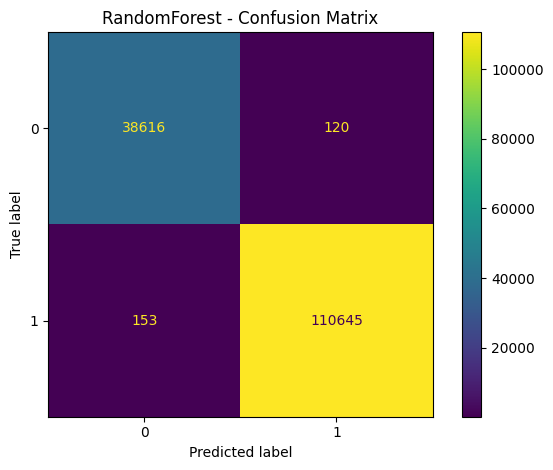

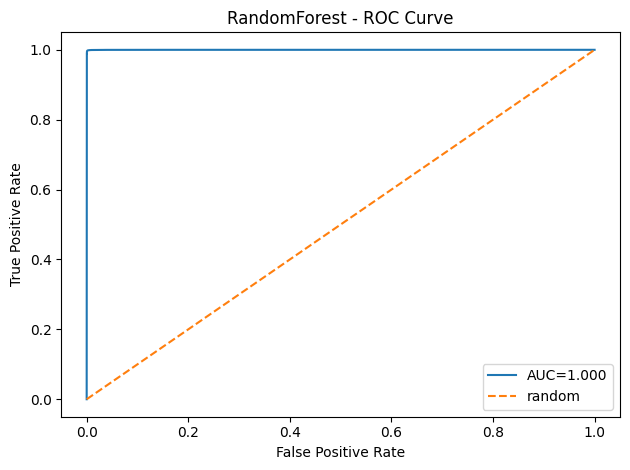

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_rf, y_score_rf, name="RandomForest")
plot_confusion(y_test, y_pred_rf, title="RandomForest - Confusion Matrix")
plot_roc(y_test, y_score_rf, title="RandomForest - ROC Curve")

XG Boost Model

In [12]:
# !pip install xgboost


===== XGBoost =====
Accuracy          : 0.9977
Balanced Accuracy : 0.9977
F1-score          : 0.9985
ROC AUC           : 0.9999


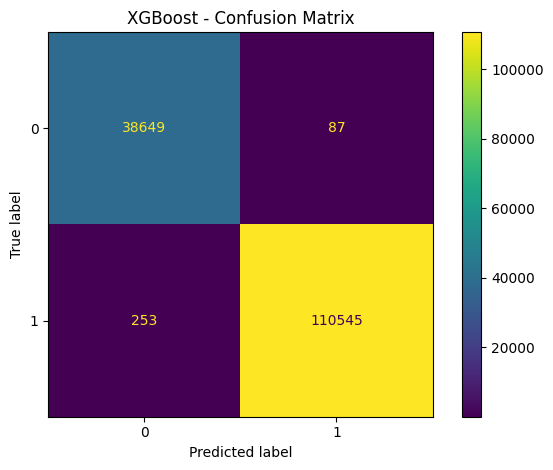

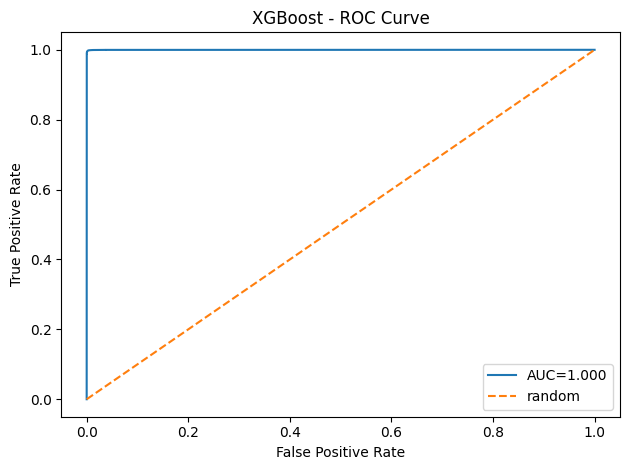

In [13]:
from xgboost import XGBClassifier

# class imbalance 
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_score_xgb = xgb.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_xgb, y_score_xgb, name="XGBoost")
plot_confusion(y_test, y_pred_xgb, title="XGBoost - Confusion Matrix")
plot_roc(y_test, y_score_xgb, title="XGBoost - ROC Curve")

LightGBM Model

In [ ]:
# !pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.9 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\wpca4\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


[LightGBM] [Info] Number of positive: 258527, number of negative: 90385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2490
[LightGBM] [Info] Number of data points in the train set: 348912, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

===== LightGBM =====
Accuracy          : 0.9981
Balanced Accuracy : 0.9980
F1-score          : 0.9987
ROC AUC           : 1.0000


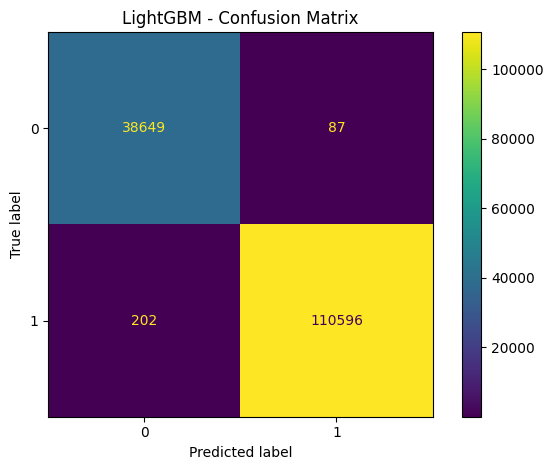

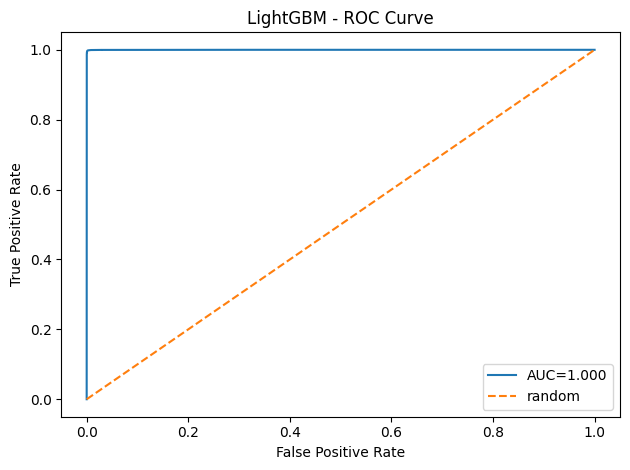

In [16]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    num_leaves=50,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

lgb.fit(X_train, y_train)

y_pred_lgb  = lgb.predict(X_test)
y_score_lgb = lgb.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_lgb, y_score_lgb, name="LightGBM")
plot_confusion(y_test, y_pred_lgb, title="LightGBM - Confusion Matrix")
plot_roc(y_test, y_score_lgb, title="LightGBM - ROC Curve")